# Scientific Validity of PPI++ for Binary Mean Estimation

This notebook provides empirical evidence that GLIDE's **Prediction-Powered Inference (PPI++)** implementation is statistically valid.

**Setup:** We estimate the mean of a binary outcome (e.g., the pass rate of an LLM-as-a-judge evaluation). We have:
- A small set of **true labels** (`y_true`) — expensive but unbiased
- A large set of **proxy labels** (`y_proxy`) — cheap but potentially biased

PPI++ combines both to produce confidence intervals that are:
1. **Valid** — they cover the true mean at the specified rate (e.g. 90% confidence)
2. **Shorter** — as compared to those obtained with true labels only, especially when the proxy is strongly correlated with the truth

We test these two claims empirically across a range of proxy/true correlation levels.

### Table of contents

- Experiment Parameters
- Data Generation
- Inference Results
- Converage Validity
- Confidence Interval Width
- Effective Sample Size
- Summary

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from glide.core.dataset import Dataset
from glide.core.simulated import generate_dataset_binary
from glide.estimators import ClassicalMeanEstimator, PPIMeanEstimator

## Experiment Parameters

We fix all parameters up front so every section of this notebook uses a consistent setup. We define :

`CONFIDENCE_LEVEL` : the confidence level at which we will compute confidence intervals.

`N_TRUE` : the number of human annotated samples we will use in each experiment.

`N_PROXY` : the number of proxy labeled samples used.

`TRUE_MEAN` : the true mean value of human labels.

`PROXY_MEAN` : the (biased) proxy mean value;

`N_SEEDS` : the number of simulations we will make in our Monte Carlo experiments.

We also define the correlation levels that we will consider in the experiments.

> **Note on correlation bounds:** Depending on the values of `TRUE_MEAN` and `PROXY_MEAN`, extreme correlation values (close to 0 or 1) may not be possible. Correlation sweeps are kept within these limit.

Finally, we define the methods that we will compare which are the following :

- `True only` : refers to using true human labels only to compute estimates in the conventional way

- `Proxy only` : refers to using proxy labels only.

- `PPI++` : refers to Prediction Power Inference with Power Tuning, details are provided below.

In [ ]:
CONFIDENCE_LEVEL = 0.9   # fixed throughout — 90% Confidence Interval
N_TRUE = 500
N_PROXY = 1000
TRUE_MEAN = 0.55
PROXY_MEAN = 0.5
N_SEEDS = 1000

METHODS = ['True only', 'Proxy only', 'PPI++']

correlations   = np.arange(0.1, 0.95, 0.1)
correlations_lmh = [0.2, 0.5, 0.8]  # low, medium and high values
corr_labels    = ["Low", "Medium", "High"]

## Data Generation

We use `generate_dataset_binary` to simulate a realistic evaluation scenario.
It generates correlated binary labels `(y_true, y_proxy)` for `N_TRUE` items, plus `N_PROXY` items with only `y_proxy` available.

The `correlation` parameter controls the Pearson correlation between true and proxy labels on the labeled subset.

In [3]:
# Single example dataset for illustration
dataset = generate_dataset_binary(
    n=N_TRUE,
    N=N_PROXY,
    true_mean=TRUE_MEAN,
    proxy_mean=PROXY_MEAN,
    correlation=0.8,
    random_seed=42,
)

data_array = dataset.to_numpy(fields=["y_true", "y_proxy"])

In the following sections, we will perform Monte Carlo experiments to estimate confidence interval width among other things.

This consists in running `N_SEEDS` simulations where we generate data, compute a confidence interval and measure its width each time. We end up up with `N_SEEDS` sample values for the measured quantity that we can use to compute statistics.

The same method can be used to evaluate coverage which will be defined and illustrated below.

## Inference Results

We compare three estimators:

| Method | Data used | Notes |
|--------|-----------|-------|
| **True only** | `y_true` | Classical CLT Confidence Interval — the gold standard for validity |
| **Proxy only** | `y_proxy` | Biased — cheap but wrong |
| **PPI++** | `y_true` + `y_proxy` (rectified) | Recommended method — valid and efficient |

The function below computes means and confidence intervals using all three methods.

In [4]:
def generate_estimates(dataset, confidence_level=CONFIDENCE_LEVEL):
    """Return mean, std, and Confidence Interval for all three methods."""
    # --- PPI++ ---
    ppi_result = PPIMeanEstimator().estimate(
        dataset,
        y_true_field="y_true",
        y_proxy_field="y_proxy",
        confidence_level=confidence_level,
    )

    # --- Classical baselines ---
    true_only_result = ClassicalMeanEstimator().estimate(
        dataset, y_field="y_true", confidence_level=confidence_level
    )
    proxy_only_result = ClassicalMeanEstimator().estimate(
        dataset, y_field="y_proxy", confidence_level=confidence_level
    )

    return {
        'True only': {
            "mean": true_only_result.mean,
            "std":  true_only_result.std,
            "CI":   (true_only_result.confidence_interval.lower_bound,
                     true_only_result.confidence_interval.upper_bound),
        },
        'Proxy only': {
            "mean": proxy_only_result.mean,
            "std":  proxy_only_result.std,
            "CI":   (proxy_only_result.confidence_interval.lower_bound,
                     proxy_only_result.confidence_interval.upper_bound),
        },
        'PPI++': {
            "mean": ppi_result.mean,
            "std":  ppi_result.std,
            "CI":   (ppi_result.confidence_interval.lower_bound,
                     ppi_result.confidence_interval.upper_bound),
            "ess":  ppi_result.effective_sample_size,
        },
    }

PPI++ is implemented by the `PPIMeanEstimator` whereas `ClassicalMeanEstimator` implements conventional mean estimation.

In [ ]:
def simulate_all(correlation, n_seeds=N_SEEDS):
    """Single Monte Carlo loop: cache per-seed mean, std, and ESS for each method."""
    means = {method: np.zeros(n_seeds) for method in METHODS}
    stds  = {method: np.zeros(n_seeds) for method in METHODS}
    ess   = np.zeros(n_seeds)

    for seed in range(n_seeds):
        ds = generate_dataset_binary(
            n=N_TRUE, N=N_PROXY,
            true_mean=TRUE_MEAN, proxy_mean=PROXY_MEAN,
            correlation=correlation, random_seed=seed,
        )
        est = generate_estimates(ds)
        for method in METHODS:
            means[method][seed] = est[method]['mean']
            stds[method][seed]  = est[method]['std']
        ess[seed] = est['PPI++']['ess']

    stats = {method: {'means': means[method], 'stds': stds[method]} for method in METHODS}
    stats['PPI++']['ess'] = ess
    return stats


def compute_hits(stats, confidence_level):
    """Return per-seed hit indicators {method: float array} at the given confidence level."""
    z = norm.ppf((1 + confidence_level) / 2)
    hits = {}
    for method in METHODS:
        lo = stats[method]['means'] - z * stats[method]['stds']
        hi = stats[method]['means'] + z * stats[method]['stds']
        hits[method] = ((lo <= TRUE_MEAN) & (TRUE_MEAN <= hi)).astype(float)
    return hits


def coverage_with_errbar(hit_array, confidence_level=CONFIDENCE_LEVEL):
    """Estimate empirical coverage + Confidence Interval via ClassicalMeanEstimator on per-seed hit indicators."""
    ds = Dataset([{"hit": h} for h in hit_array])
    r = ClassicalMeanEstimator().estimate(ds, y_field="hit", confidence_level=confidence_level)
    return r.mean, r.confidence_interval.lower_bound, r.confidence_interval.upper_bound

## Coverage Validity

A confidence interval is **valid** if it is built using a method that reliably captures the true value. For example, a 95% confidence interval is valid if, when you repeat the experiment many times and compute a new interval each time, around 95% of those intervals end up containing the true value.

We check this empirically via a Monte Carlo experiment as described above and count how often each method's confidence interval covers `TRUE_MEAN`.

> **Key question:** Does PPI++ maintain valid coverage, or does it sacrifice it for shorter intervals?

### Coverage vs confidence level — for three correlation levels

We sweep the confidence level from 0.55 to 0.95 and plot the observed coverage.
For a valid method, the dots should fall on or above the black diagonal $y = \text{confidence\_level}$.

We do this for **low** ($\rho = 0.2$), **medium** ($\rho = 0.5$), and **high** ($\rho = 0.8$) proxy correlation.

In [6]:
# Make simulation for each correlation level
raw_stats = {correlation: simulate_all(correlation) for correlation in correlations}

confidence_levels = np.arange(0.55, 1.00, 0.05)

# Derive coverage for every (correlation, confidence_level) pair
coverage = {}
for correlation in correlations_lmh:
    coverage[correlation] = {}
    for confidence_level in confidence_levels:
        hits = compute_hits(raw_stats[correlation], confidence_level)
        coverage[correlation][confidence_level] = {method: float(np.mean(hits[method])) for method in METHODS}

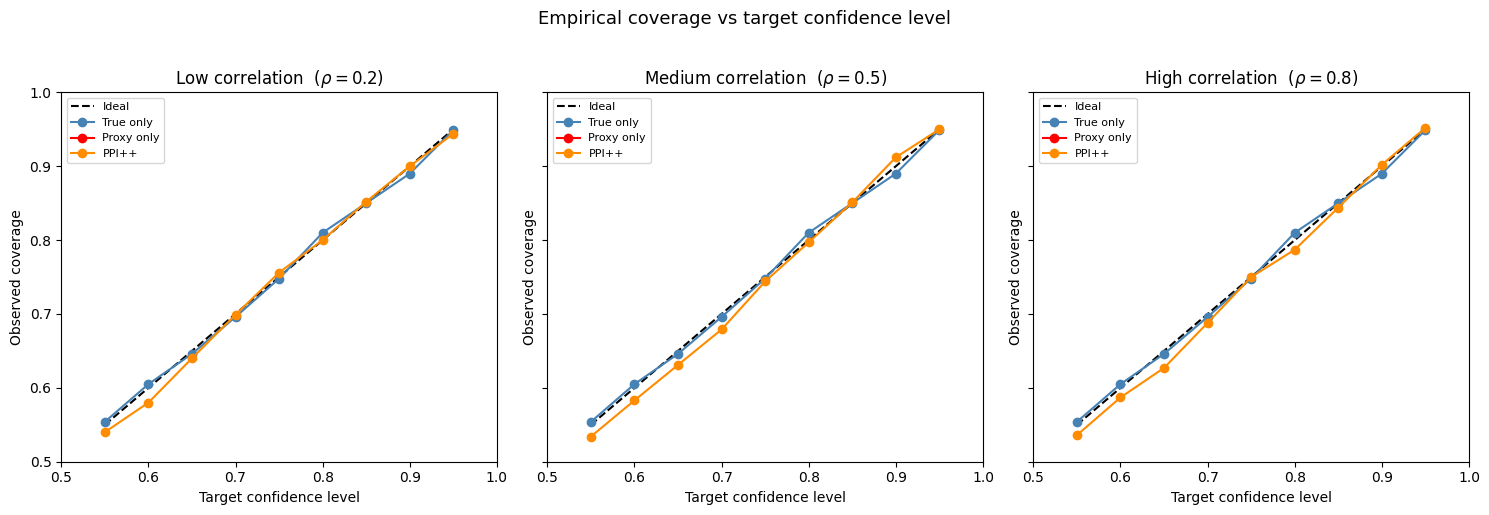

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {'True only': 'steelblue', 'PPI++': 'darkorange', 'Proxy only': 'red'}

for ax, correlation, label in zip(axes, correlations_lmh, corr_labels):
    ax.plot(confidence_levels, confidence_levels, color='black', lw=1.5,
            linestyle='--', label='Ideal')
    for method in METHODS:
        obs = [coverage[correlation][cl][method] for cl in confidence_levels]
        ax.plot(confidence_levels, obs, marker='o', label=method, color=colors[method])
    ax.set_xlabel('Target confidence level')
    ax.set_ylabel('Observed coverage')
    ax.set_title(f'{label} correlation  ($\\rho = {correlation}$)')
    ax.legend(fontsize=8)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0.5, 1.0)

fig.suptitle('Empirical coverage vs target confidence level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both **PPI++** and **True only** track the diagonal closely across all correlation levels, confirming that PPI++ achieves valid coverage regardless of proxy quality. The Proxy only method does not show up because it uses biased data so that its coverage is invalid (close to zero).

---

### Coverage vs correlation — for fixed confidence level = 0.9

We now fix the confidence level at 90% and vary the proxy-true correlation from 0.1 to 0.9.
This shows that PPI++' validity does not degrade as the proxy becomes weaker.

In [ ]:
coverage_by_corr    = {}   # {rho: {method: observed mean coverage}}
coverage_ci_by_corr = {}   # {rho: {method: (lower, upper) Confidence Interval on coverage}}

for correlation in correlations:
    hits = compute_hits(raw_stats[correlation], CONFIDENCE_LEVEL)
    coverage_by_corr[correlation]    = {}
    coverage_ci_by_corr[correlation] = {}
    for method in METHODS:
        mean_cov, lo, hi = coverage_with_errbar(hits[method])
        coverage_by_corr[correlation][method]    = mean_cov
        coverage_ci_by_corr[correlation][method] = (lo, hi)

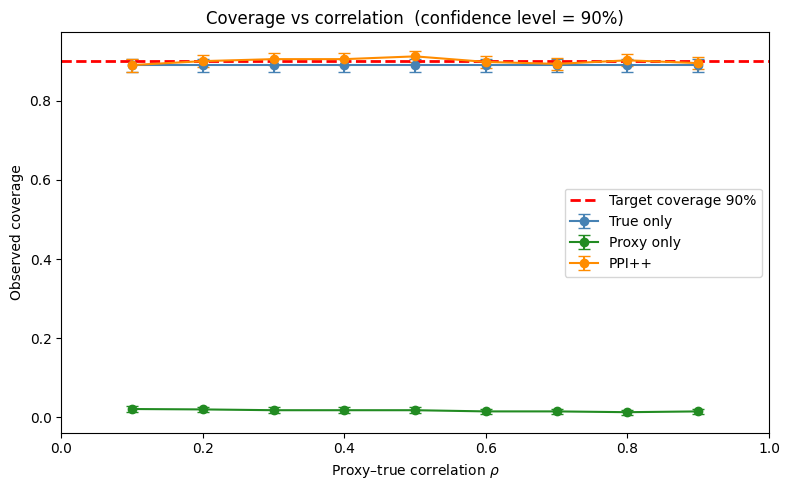

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
method_colors = {'True only': 'steelblue', 'Proxy only': 'forestgreen', 'PPI++': 'darkorange'}

for method in METHODS:
    obs  = [coverage_by_corr[correlation][method] for correlation in correlations]
    lo   = [coverage_ci_by_corr[correlation][method][0] for correlation in correlations]
    hi   = [coverage_ci_by_corr[correlation][method][1] for correlation in correlations]
    yerr = [
        [obs_ - lo_ for obs_, lo_ in zip(obs, lo)],
        [hi_ - obs_ for hi_, obs_ in zip(hi, obs)],
    ]
    ax.errorbar(correlations, obs, yerr=yerr, marker='o', label=method,
                color=method_colors[method], capsize=4)

ax.axhline(y=CONFIDENCE_LEVEL, color='red', linestyle='--', lw=2,
           label=f'Target coverage {CONFIDENCE_LEVEL:.0%}')
ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('Observed coverage')
ax.set_title(f'Coverage vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

Note that **Proxy only**, as before, under-covers because the proxy is biased (proxy mean ≠ true mean). Only **PPI++** and **True only** remain valid across all correlation levels.

---

## Confidence Interval Width

Coverage validity is necessary but not sufficient — we also want **short** intervals. PPI++'s promise is that by leveraging the unlabeled proxy data, it achieves the same validity as using labeled data alone, but with a shorter interval when the proxy is informative.

We run a Monte Carlo experiment over confidence interval widths and report the **mean** and the **10th–90th percentile band** to capture variability.

In [10]:
z_score = norm.ppf((1 + CONFIDENCE_LEVEL) / 2)
width_by_corr = {
    correlation: {method: 2 * z_score * raw_stats[correlation][method]['stds'] for method in METHODS}
    for correlation in correlations
}

The shaded bands show the 10th–90th percentile range across Monte Carlo runs.
At high correlation, PPI's confidence interval should be substantially narrower than true-only.

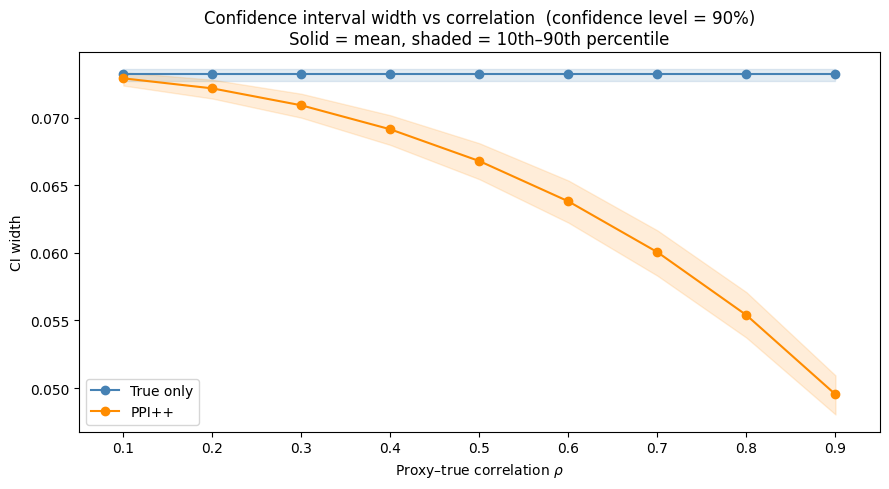

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_methods_w = ['True only', 'PPI++']
colors_w = {'True only': 'steelblue', 'PPI++': 'darkorange'}

for method in plot_methods_w:
    means_w = [np.mean(width_by_corr[correlation][method]) for correlation in correlations]
    q10 = [np.percentile(width_by_corr[correlation][method], 10) for correlation in correlations]
    q90 = [np.percentile(width_by_corr[correlation][method], 90) for correlation in correlations]
    ax.plot(correlations, means_w, marker='o', label=method, color=colors_w[method])
    ax.fill_between(correlations, q10, q90, alpha=0.15, color=colors_w[method])

ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('Confidence Interval width')
ax.set_title(f'Confidence interval width vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})\n'
             'Solid = mean, shaded = 10th–90th percentile')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

As expected, PPI++' interval width decreases with increasing correlation — leveraging the unlabeled proxy data is only beneficial when the proxy is informative.

---

## Effective Sample Size

A natural summary of PPI's efficiency gain is the **Effective Sample Size (ESS)**: *it is the number of samples needed by the True only method to achieve the same confidence interval width as PPI++ with the current sample size*

Since confidence interval width $\propto 1/\sqrt{n}$, we can estimate ESS empirically as:

$$\text{ESS}(\rho) = N_{\text{true}} \times \left(\frac{\bar{w}_{\text{True only}}}{\bar{w}_{\text{PPI++}}}\right)^2,$$

where $\bar{w}_{\text{True only}}$ and $\bar{w}_{\text{PPI++}}$ are the confidence interval widths for True only and PPI++ respectively.

When $\rho = 0,~$ ESS $\approx N_{\text{labeled}}$ (no gain)$.~$ As $\rho \to 1,~$ ESS grows — PPI++ can be equivalent to having a much larger labeled dataset.

In [12]:
ess_mean = [np.mean(raw_stats[correlation]['PPI++']['ess']) for correlation in correlations]
ess_q10  = [np.percentile(raw_stats[correlation]['PPI++']['ess'], 10) for correlation in correlations]
ess_q90  = [np.percentile(raw_stats[correlation]['PPI++']['ess'], 90) for correlation in correlations]

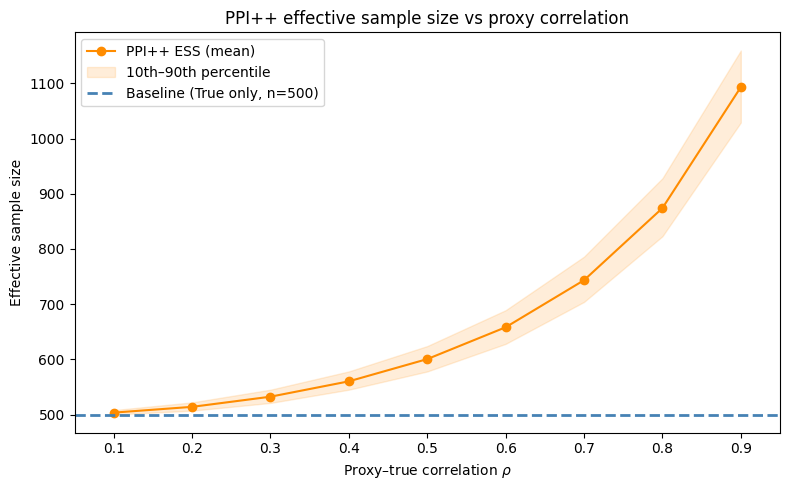

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(correlations, ess_mean, marker='o', color='darkorange', label='PPI++ ESS (mean)')
ax.fill_between(correlations, ess_q10, ess_q90, alpha=0.15, color='darkorange',
                label='10th–90th percentile')
ax.axhline(y=N_TRUE, color='steelblue', linestyle='--', lw=2,
           label=f'Baseline (True only, n={N_TRUE})')
ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('Effective sample size')
ax.set_title('PPI++ effective sample size vs proxy correlation')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()


## Summary

This notebook has empirically validated that GLIDE's PPI++ implementation satisfies two key statistical properties:

| Property | Result |
|----------|--------|
| **Coverage validity** | PPI++ achieves the nominal coverage across all correlation levels and confidence levels tested |
| **Efficiency** | PPI++ produces shorter confidence intervals than labeled-only whenever $\rho > 0$, with the gain growing quadratically with correlation |

Crucially, the biased baseline (**Proxy only**) fails the coverage test — it appears precise but is systematically wrong. PPI++ avoids this by correcting for proxy bias using the labeled subset.

The ESS analysis shows that with a proxy correlation of $\rho = 0.9,~$ PPI++ is equivalent to having roughly **twice more labeled data** — a significant practical gain in scenarios where true annotation is expensive.